<a href="https://colab.research.google.com/github/VladousSparrowous/HSE-homeworks/blob/main/image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from typing import Callable

import numpy as np
import pandas as pd

import torch.nn as nn
import torch.nn.functional as F

import os, torch, shutil
from glob import glob; from PIL import Image
from torch.utils.data import random_split, Dataset, DataLoader
from torchvision import transforms as T
torch.manual_seed(2024)

from PIL import Image
import matplotlib.pyplot as plt

from tqdm import trange
from tqdm.auto import tqdm

from IPython.display import clear_output

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using {} device".format(device))

Using cuda device


# знакомство с данными
провкерка дисбаланса классов и удаление лишней картинки(из-за неё падало обучение)

In [ ]:
df_train = pd.read_csv('/kaggle/input/competitions/dl-5-image-classification-2026/train-labels.csv')
df_train

,image,label
0,21310.jpg,Sunglasses
1,8993.jpg,Sports Shoes
2,33363.jpg,Wallets
3,27744.jpg,Handbags
4,11603.jpg,Kurtas
...,...,...
16571,57536.jpg,Belts
16572,56337.jpg,Watches
16573,29762.jpg,Watches
16574,11515.jpg,Heels


In [ ]:
import os


folder_path = '/kaggle/input/competitions/dl-5-image-classification-2026/train'

file_names = os.listdir(folder_path)

print(f"Найдено файлов: {len(file_names)}")
print("Первые 10 файлов:", file_names[:10])

Найдено файлов: 16575
Первые 10 файлов: ['22735.jpg', '38246.jpg', '44758.jpg', '59454.jpg', '34410.jpg', '6234.jpg', '36765.jpg', '38745.jpg', '28578.jpg', '48069.jpg']


In [ ]:
f_n = list(df_train['image'])
print(set(f_n) - set(file_names))

{'39401.jpg'}


In [ ]:
df_train[df_train['image'] == '39401.jpg']

,image,label
16043,39401.jpg,Jeans


In [ ]:
df_train = df_train.drop(16043)
df_train = df_train.reset_index(drop=True)

In [ ]:
labels = df_train.label.unique()
labels

array(['Sunglasses', 'Sports Shoes', 'Wallets', 'Handbags', 'Kurtas',
       'Casual Shoes', 'Shirts', 'Perfume and Body Mist', 'Tshirts',
       'Tops', 'Flip Flops', 'Backpacks', 'Watches', 'Belts',
       'Formal Shoes', 'Socks', 'Jeans', 'Heels', 'Sandals', 'Briefs'],
      dtype=object)

In [ ]:
df_aaa = df_train.groupby(['label']).count()
df_aaa

,image
label,
Backpacks,362
Belts,407
Briefs,425
Casual Shoes,1423
Flip Flops,458
Formal Shoes,319
Handbags,879
Heels,661
Jeans,304


In [ ]:
map_label_to_int = {}
map_int_to_label = {}

for i, label in enumerate(labels):
    map_label_to_int[label] = i
    map_int_to_label[i] = label

# обработка данных
За основу я взял класс FashionDataset в ноутбуке из примера.
В своих экспериментах я пробовал разные варианты bs(batch size) - 16, 32, 64
Лучшим вариантом оказался 64, возможно это связанно с лучшей обобщающей способностью при таком размере.
Я пробовал простую аугментацию:
```python
     T.RandomHorizontalFlip(p=0.5),
     T.RandomRotation(10),
     T.ColorJitter(brightness=0.2, contrast=0.2),
```
но она не дала какого-то прироста по метрикам.

In [ ]:
class FashionDataset(Dataset):
    """
    Dataset для загрузки данных.

    Args:
        df_meta (pd.DataFrame): DataFrame, содержащий метаданные изображений.
            Ожидается, что DataFrame имеет как минимум два столбца:
            - Первый столбец содержит имя файла изображения.
            - Второй столбец содержит метку класса для этого изображения.
        img_path (str): Путь к директории, содержащей изображения.
        transforms (Callable): Функция преобразования для применения к изображениям.
            Например, `torchvision.transforms.Compose` может быть использован для цепочки преобразований.
            По умолчанию: None.
    """

    def __init__(self, df_meta: pd.DataFrame, img_path: str, transforms: Callable = None):
        super().__init__()
        self.df_meta = df_meta
        self.img_path = img_path
        self.transforms = transforms

    def __getitem__(self, idx: int) -> (torch.tensor, torch.tensor):
        """
        Возвращает один элемент набора данных в виде кортежа из тензора изображения и тензора метки.

            Args:
                idx (int): Индекс элемента, который необходимо получить.

            Returns:
                tuple: Кортеж, содержащий:
                    - img_tensor (torch.tensor): Тензор изображения после применения преобразований.
                    - label_tensor (torch.tensor): Тензор метки класса.
        """

        img_name, label = self.df_meta.iloc[idx]
        img = Image.open(os.path.join(self.img_path, img_name))

        img_tensor = img.convert("RGB")

        if self.transforms is not None:
            img_tensor = self.transforms(img_tensor)

        label_int = map_label_to_int[label]
        label_tensor = torch.tensor(label_int, dtype=torch.long)

        return (img_tensor, label_tensor)


    def __len__(self) -> int:
        """
        Возвращает длину набора данных.

            Returns:
                int: Количество элементов в наборе данных.
        """

        return self.df_meta.shape[0] - 1

In [ ]:
def get_dls(root, transformations, bs, split = [0.9, 0.05, 0.05], ns = 4):

    ds = FashionDataset(df_meta=df_train,  img_path=root, transforms=transformations)

    total_len = len(ds)
    tr_len = int(total_len * split[0])
    vl_len = int(total_len * split[1])
    ts_len = total_len - (tr_len + vl_len)

    tr_ds, vl_ds, ts_ds = random_split(dataset = ds, lengths = [tr_len, vl_len, ts_len])

    tr_dl, val_dl, ts_dl = DataLoader(tr_ds, batch_size = bs, shuffle = True, num_workers = ns), DataLoader(vl_ds, batch_size = bs, shuffle = False, num_workers = ns), DataLoader(ts_ds, batch_size = 1, shuffle = False, num_workers = ns)

    return tr_dl, val_dl, ts_dl


root = "/kaggle/input/competitions/dl-5-image-classification-2026/train/"

mean, std, im_size = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225], 224
tfs = T.Compose([T.Resize((im_size, im_size)),
                 T.RandomHorizontalFlip(p=0.5),
                 T.RandomRotation(10),
                 T.ColorJitter(brightness=0.2, contrast=0.2),
                 T.ToTensor(),
                 T.Normalize(mean = mean, std = std)])
tr_dl, val_dl, ts_dl = get_dls(root = root, transformations = tfs, bs = 32)

print(len(tr_dl)); print(len(val_dl)); print(len(ts_dl))

467
26
830


In [ ]:
print(map_label_to_int)
print(map_int_to_label)

{'Sunglasses': 0, 'Sports Shoes': 1, 'Wallets': 2, 'Handbags': 3, 'Kurtas': 4, 'Casual Shoes': 5, 'Shirts': 6, 'Perfume and Body Mist': 7, 'Tshirts': 8, 'Tops': 9, 'Flip Flops': 10, 'Backpacks': 11, 'Watches': 12, 'Belts': 13, 'Formal Shoes': 14, 'Socks': 15, 'Jeans': 16, 'Heels': 17, 'Sandals': 18, 'Briefs': 19}
{0: 'Sunglasses', 1: 'Sports Shoes', 2: 'Wallets', 3: 'Handbags', 4: 'Kurtas', 5: 'Casual Shoes', 6: 'Shirts', 7: 'Perfume and Body Mist', 8: 'Tshirts', 9: 'Tops', 10: 'Flip Flops', 11: 'Backpacks', 12: 'Watches', 13: 'Belts', 14: 'Formal Shoes', 15: 'Socks', 16: 'Jeans', 17: 'Heels', 18: 'Sandals', 19: 'Briefs'}


# модели и обучение
я пробовал разные предобученные модели и два варианта Transfer Learning - Fine-tuning и Feature Extraction с Head Swapping

для замены голов написал класс:
```python
backbone = timm.create_model(model_name, pretrained = True, num_classes = 0)

class CustomClassifier(nn.Module):
    def __init__(self, backbone, num_classes=20, dropout=0.3):
        super().__init__()
        self.backbone = backbone

        for param in self.backbone.parameters():
            param.requires_grad = False
        self.feature_dim = backbone.num_features
        self.feature_dim
        self.classifier = nn.Sequential(
            ...
        )
    
    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

m = CustomClassifier(backbone, num_classes=20, dropout=0.3)
```
* модели rexnet_100, rexnet_150, rexnet_200, rexnet_300
  
(цитата про этот класс моделей с их карточки на huggingface)
> RexNet
Rank Expansion Networks (ReXNets) follow a set of new design principles for designing bottlenecks in image classification models. Authors refine each layer by 1) expanding the input channel size of the convolution layer and 2) replacing the ReLU6s.


  модель этого класса, а именно 'rexnet_150' с батчем 64 и без аугментации без замены головы
  ```python
  m = timm.create_model(model_name, pretrained = True, num_classes = 20)
  ```
  дала лучший результат.
  хотя с 150 и 200, я добавлял аугментацию(dropout)  и менял головы (замораживая веса и обучая их)
  ```python
  param.requires_grad = False
  ```
  , с маленькой(3) наблюдалось переобучение, а с двумя другими я эксперементировал.

    
1.
```python
     self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(self.feature_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(1024, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(1024, num_classes)
        )
```
2.
```python
     self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(self.feature_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )
```
3.
```python
    self.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(self.feature_dim, 512),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(512, num_classes)
    )
```
    
    
* трансформеры - vit_small_patch16_rope_224.naver_in1k и vit_base_patch16_rope_224.naver_in1k, предобученные на ImageNet-1k.
я обучал с батчем 16 и 64, с аугментацией и без, получал результаты немного хуже rexnet, base модель показывала признаки переобучения(не стабильное изменение loss c первых итераций), для base модели я добавлял регуляризацию(dropout), переобучение снизилось, но результат не стал лучше.

Наверно для них нужно больше данных или большая аугментация
```
m = timm.create_model("vit_small_patch16_rope_224.naver_in1k", pretrained = True, num_classes = 20, dropout=0.2)  
```
* convnext модели - convnextv2_nano, convnext_small менял головы с батчем 32, получил результаты на уровне трансформеров

In [ ]:
model_name = 'rexnet_150'

In [ ]:
import timm, torchmetrics
from tqdm import tqdm

backbone = timm.create_model(model_name, pretrained = True, num_classes = 0)

class CustomClassifier(nn.Module):
    def __init__(self, backbone, num_classes=20, dropout=0.3):
        super().__init__()
        self.backbone = backbone

        for param in self.backbone.parameters():
            param.requires_grad = False
        self.feature_dim = backbone.num_features
        self.feature_dim
        self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(self.feature_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(1024, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(1024, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

m = CustomClassifier(backbone, num_classes=20, dropout=0.3)

def train_setup(m):
    return m.to("cuda").eval(), 5, "cuda", torch.nn.CrossEntropyLoss(), torch.optim.Adam(params = m.parameters(), lr = 3e-4)

def to_device(batch, device):
    return batch[0].to(device), batch[1].to(device)

def get_metrics(model, ims, gts, loss_fn, epoch_loss, epoch_acc, epoch_f1):
    preds = model(ims)
    loss = loss_fn(preds, gts)
    return loss, epoch_loss + (loss.item()), epoch_acc + (torch.argmax(preds, dim = 1) == gts).sum().item(), epoch_f1 + f1_score(preds, gts)

m, epochs, device, loss_fn, optimizer = train_setup(m)

f1_score = torchmetrics.F1Score(task = "multiclass", num_classes = 20, average='weighted').to(device)
save_prefix, save_dir = "leaf", "saved_models"

print("Start training...")

best_acc, best_loss, threshold, not_improved, patience = 0, float("inf"), 0.01, 0, 3
tr_losses, val_losses, tr_accs, val_accs, tr_f1s, val_f1s = [], [], [], [], [], []

best_loss = float(torch.inf)

for epoch in range(epochs):
    # if epoch == 1: break

    epoch_loss, epoch_acc, epoch_f1 = 0, 0, 0
    for idx, batch in tqdm(enumerate(tr_dl)):
        # if idx == 2: break

        ims, gts = to_device(batch, device)

        loss, epoch_loss, epoch_acc, epoch_f1 = get_metrics(m, ims, gts, loss_fn, epoch_loss, epoch_acc, epoch_f1)
        optimizer.zero_grad(); loss.backward(); optimizer.step()

    tr_loss_to_track = epoch_loss / len(tr_dl)
    tr_acc_to_track  = epoch_acc  / len(tr_dl.dataset)
    tr_f1_to_track   = epoch_f1   / len(tr_dl)
    tr_losses.append(tr_loss_to_track); tr_accs.append(tr_acc_to_track); tr_f1s.append(tr_f1_to_track)

    print(f"{epoch + 1}-epoch train process is completed!")
    print(f"{epoch + 1}-epoch train loss          -> {tr_loss_to_track:.3f}")
    print(f"{epoch + 1}-epoch train accuracy      -> {tr_acc_to_track:.3f}")
    print(f"{epoch + 1}-epoch train f1-score      -> {tr_f1_to_track:.3f}")

    m.eval()
    with torch.no_grad():
        val_epoch_loss, val_epoch_acc, val_epoch_f1 = 0, 0, 0
        for idx, batch in enumerate(val_dl):
            # if idx == 2: break
            ims, gts = to_device(batch, device)
            loss, val_epoch_loss, val_epoch_acc, val_epoch_f1 = get_metrics(m, ims, gts, loss_fn, val_epoch_loss, val_epoch_acc, val_epoch_f1)

        val_loss_to_track = val_epoch_loss / len(val_dl)
        val_acc_to_track  = val_epoch_acc  / len(val_dl.dataset)
        val_f1_to_track   = val_epoch_f1   / len(val_dl)
        val_losses.append(val_loss_to_track); val_accs.append(val_acc_to_track); val_f1s.append(val_f1_to_track)

        print(f"{epoch + 1}-epoch validation process is completed!")
        print(f"{epoch + 1}-epoch validation loss     -> {val_loss_to_track:.3f}")
        print(f"{epoch + 1}-epoch validation accuracy -> {val_acc_to_track:.3f}")
        print(f"{epoch + 1}-epoch validation f1-score -> {val_f1_to_track:.3f}")

        if val_loss_to_track < (best_loss + threshold):
            os.makedirs(save_dir, exist_ok = True)
            best_loss = val_loss_to_track
            torch.save(m.state_dict(), f"{save_dir}/{save_prefix}_best_model.pth")

        else:
            not_improved += 1
            print(f"Loss value did not decrease for {not_improved} epochs")
            if not_improved == patience:
                print(f"Stop training since loss value did not decrease for {patience} epochs.")
                break

model.safetensors:   0%|          | 0.00/39.2M [00:00<?, ?B/s]

Start training...


467it [03:09,  2.46it/s]

1-epoch train process is completed!
1-epoch train loss          -> 0.412
1-epoch train accuracy      -> 0.861
1-epoch train f1-score      -> 0.850


1-epoch validation process is completed!
1-epoch validation loss     -> 0.224
1-epoch validation accuracy -> 0.917
1-epoch validation f1-score -> 0.917


...

4-epoch train process is completed!
4-epoch train loss          -> 0.149
4-epoch train accuracy      -> 0.942
4-epoch train f1-score      -> 0.942


4-epoch validation process is completed!
4-epoch validation loss     -> 0.198
4-epoch validation accuracy -> 0.924
4-epoch validation f1-score -> 0.923
Loss value did not decrease for 1 epochs


467it [02:53,  2.70it/s]

5-epoch train process is completed!
5-epoch train loss          -> 0.139
5-epoch train accuracy      -> 0.945
5-epoch train f1-score      -> 0.945


5-epoch validation process is completed!
5-epoch validation loss     -> 0.197
5-epoch validation accuracy -> 0.926
5-epoch validation f1-score -> 0.922
Loss value did not decrease for 2 epochs


In [ ]:
print(timm.list_models('*rexnet*', pretrained=True))

['rexnet_100.nav_in1k', 'rexnet_130.nav_in1k', 'rexnet_150.nav_in1k', 'rexnet_200.nav_in1k', 'rexnet_300.nav_in1k', 'rexnetr_200.sw_in12k', 'rexnetr_200.sw_in12k_ft_in1k', 'rexnetr_300.sw_in12k', 'rexnetr_300.sw_in12k_ft_in1k']


отрисовка графиков обучения

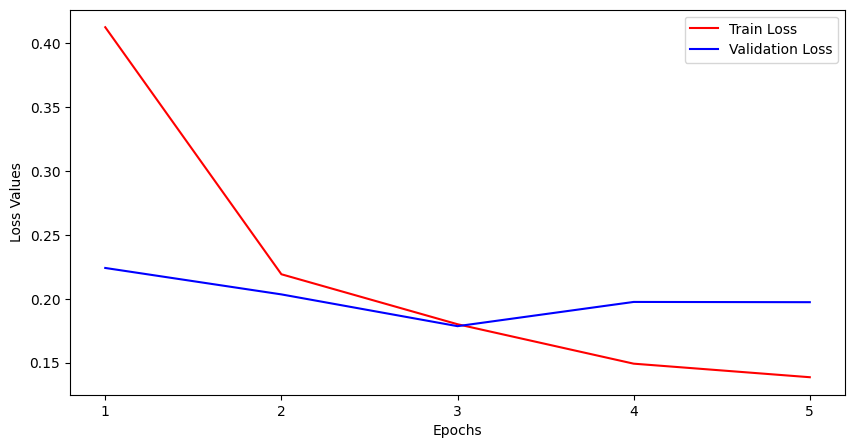

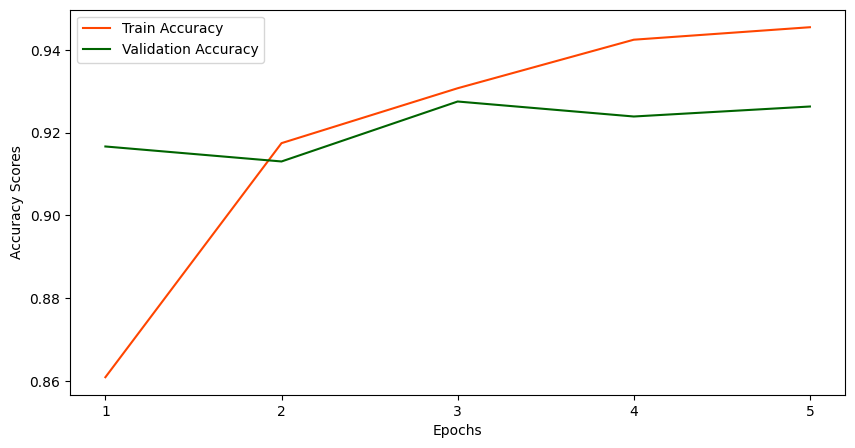

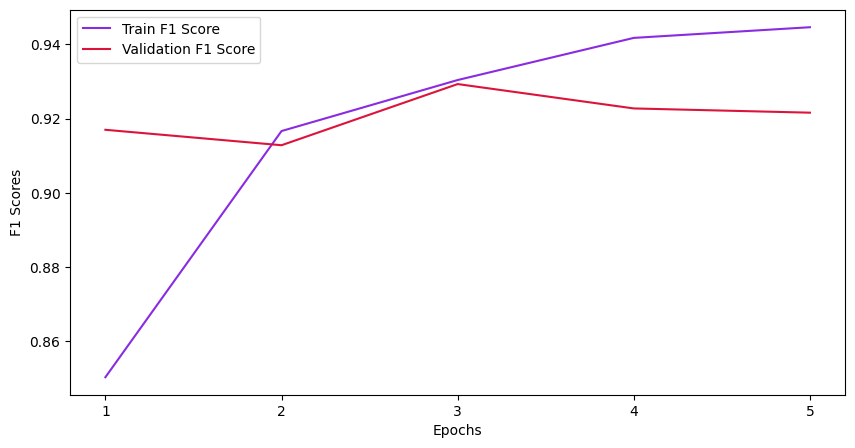

In [ ]:
class PlotLearningCurves:

    def __init__(self, tr_losses, val_losses, tr_accs, val_accs, tr_f1s, val_f1s):

        self.tr_losses, self.val_losses, self.tr_accs, self.val_accs, self.tr_f1s, self.val_f1s = tr_losses, val_losses, tr_accs, val_accs, tr_f1s, val_f1s

    def plot(self, array_1, array_2, label_1, label_2, color_1, color_2):

        plt.plot(array_1, label = label_1, c = color_1); plt.plot(array_2, label = label_2, c = color_2)

    def create_figure(self): plt.figure(figsize = (10, 5))

    def decorate(self, ylabel, xlabel = "Epochs"):

        plt.xlabel(xlabel); plt.ylabel(ylabel)
        plt.xticks(ticks = np.arange(len(self.tr_accs)), labels = [i for i in range(1, len(self.tr_accs) + 1)])
        plt.legend(); plt.show()

    def visualize(self):

        # Figure 1
        self.create_figure()
        self.plot(array_1 = self.tr_losses, array_2 = self.val_losses, label_1 = "Train Loss", label_2 = "Validation Loss", color_1 = "red", color_2 = "blue"); self.decorate(ylabel = "Loss Values")

        # Figure 2
        self.create_figure()
        self.plot(array_1 = self.tr_accs, array_2 = self.val_accs, label_1 = "Train Accuracy", label_2 = "Validation Accuracy", color_1 = "orangered", color_2 = "darkgreen")
        self.decorate(ylabel = "Accuracy Scores")

        # Figure 3
        self.create_figure()
        self.plot(array_1 = [tr_f1.cpu() for tr_f1 in self.tr_f1s], array_2 = [vl_f1.cpu() for vl_f1 in self.val_f1s], label_1 = "Train F1 Score", label_2 = "Validation F1 Score", color_1 = "blueviolet", color_2 = "crimson"); self.decorate(ylabel = "F1 Scores")

PlotLearningCurves(tr_losses, val_losses, tr_accs, val_accs, tr_f1s, val_f1s).visualize()

# submition
функции для получения предсказаний для одной картинки и батча

In [ ]:
df_sub = pd.read_csv('/kaggle/input/competitions/dl-5-image-classification-2026/sample_submission.csv')

In [ ]:
df_sub

,image,label
0,4117.jpg,NaN
1,48551.jpg,NaN
2,18248.jpg,NaN
3,45905.jpg,NaN
4,44184.jpg,NaN
...,...,...
16569,41512.jpg,NaN
16570,52106.jpg,NaN
16571,27085.jpg,NaN
16572,51680.jpg,NaN


In [ ]:
backbone = timm.create_model(model_name, pretrained=True, num_classes=0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

best_model = CustomClassifier(backbone, num_classes=20, dropout=0.3)
best_model.load_state_dict(torch.load('/kaggle/working/saved_models/leaf_best_model.pth', map_location=device))
best_model = best_model.to(device)
best_model.eval()

CustomClassifier(
  (backbone): RexNet(
    (stem): ConvNormAct(
      (conv): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNormAct2d(
        48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): SiLU(inplace=True)
      )
    )
    (features): Sequential(
      (0): LinearBottleneck(
        (conv_dw): ConvNormAct(
          (conv): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
          (bn): BatchNormAct2d(
            48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): Identity()
          )
        )
        (act_dw): ReLU6()
        (conv_pwl): ConvNormAct(
          (conv): Conv2d(48, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNormAct2d(
            24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identi

In [ ]:
def predict_single(path):
    img = Image.open(path)
    img_tensor = img.convert("RGB")

    tfs_test = T.Compose([T.Resize((im_size, im_size)),
                 T.ToTensor(),
                 T.Normalize(mean = mean, std = std)])

    img_tensor = tfs_test(img_tensor).unsqueeze(0)

    device = next(best_model.parameters()).device
    img_tensor = img_tensor.to(device)

    with torch.no_grad():
        outputs = best_model(img_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()
    predicted_label = map_int_to_label[predicted_class]
    return predicted_label

In [ ]:
df_sub_answ = df_sub.copy()

In [ ]:
for index, rows in tqdm(df_sub.iterrows()):

    test_folder_path = '/kaggle/input/competitions/dl-5-image-classification-2026/test/test'
    file_path = os.path.join(test_folder_path, rows['image'])
    predicted_label = predict_single(file_path)
    df_sub_answ.loc[index, 'label'] = predicted_label

df_sub_answ.to_csv("submission.csv", index=False)

0it [00:00, ?it/s]/tmp/ipykernel_55/374631601.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Casual Shoes' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_sub_answ.loc[index, 'label'] = predicted_label
390it [00:18, 20.84it/s]


KeyboardInterrupt: 

In [ ]:
df_sub_answ

In [ ]:
def predict_batch(image_paths, model, batch_size=32):

    tfs_test = T.Compose([
        T.Resize((im_size, im_size)),
        T.ToTensor(),
        T.Normalize(mean=mean, std=std)
    ])

    device = next(model.parameters()).device
    predictions = []

    with torch.no_grad():
        for i in tqdm(range(0, len(image_paths), batch_size)):
            batch_paths = image_paths[i:i+batch_size]
            batch_tensors = []

            for path in batch_paths:
                img = Image.open(path).convert('RGB')
                batch_tensors.append(tfs_test(img))


            batch = torch.stack(batch_tensors).to(device)

            outputs = model(batch)
            probabilities = torch.nn.functional.softmax(outputs, dim=1)
            batch_predictions = torch.argmax(probabilities, dim=1).cpu().numpy()

            for pred_idx in batch_predictions:
                predictions.append(map_int_to_label[pred_idx])

    return predictions

test_folder_path = '/kaggle/input/competitions/dl-5-image-classification-2026/test/test'
image_paths = [os.path.join(test_folder_path, fname) for fname in df_sub['image']]

predictions = predict_batch(image_paths, best_model, batch_size=32)

df_sub_answ_fast = df_sub.copy()
df_sub_answ_fast['label'] = predictions
df_sub_answ_fast.to_csv("submission_fast.csv", index=False)